## Heart disease Predication

## Meta-Data (About Dataset)
### Context
    This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

### Content
####  Column Descriptions:
`id` (Unique id for each patient) <br>
`age`  (Age of the patient in years)<br>
`origin` (place of study)<br>
`sex` (Male/Female)<br>
`cp` chest pain type<br>
    1.  typical angina,<br>
    2.  atypical angina,<br>
    3.  non-anginal,<br>
    4.  asymptomatic<br>
`trestbps` resting blood pressure (resting blood pressure  <br>     (inmm     Hg on admission to the hospital))
`chol` (serum cholesterol in mg/dl)<br>
`fbs` (if fasting blood sugar > 120 mg/dl)<br>
`restecg` (resting electrocardiographic results)<br>
-- `Values`: [normal, stt abnormality, lv hypertrophy]<br>
`thalach`: maximum heart rate achieved<br>
`exang`: exercise-induced angina (True/ False)<br>
`oldpeak`: ST depression induced by exercise relative to rest<br>
`slope`: the slope of the peak exercise ST segment<br>
`ca`: number of major vessels (0-3) colored by fluoroscopy<br>
`thal`: [normal; fixed defect; reversible defect]<br>
`num`: the predicted attribute<br>
### Acknowledgements
## Creators:
    Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.
Relevant Papers:
Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310.
David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database."
Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61.
####  Citation Request:
The authors of the databases have requested that any publications resulting from the use of the data include the names of the principal investigator responsible for the data collection at each institution.

#### They would be:

Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
V.A. Medical Center, Long Beach and Cleveland Clinic Foundation:Robert Detrano, M.D., Ph.D.
Aims and Objective:
We will fill this after doing some exploratory Data Analyis (EDA).

Let's start the project by impoprting all the libraries that we will need in this project.



In [98]:
### importing libraries 

# 1. To handle the data
import pandas as pd
import numpy as np

# 2. For data visulate the data
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# 3. To preprocess the data
from sklearn.preprocessing  import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# 4. import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 5. For Data spliting
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
# 6. for classification task
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
# from xgboost import XGBClassifier
# 7. Matrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
 # import pipeline
from sklearn.pipeline import Pipeline

# 8. warnings
import warnings
warnings.filterwarnings('ignore')


### Load the dataset

In [70]:
df = pd.read_csv('heart_disease_uci.csv')
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Exploratry Data Analysis (EDA)
#### Explore each column

In [3]:
# check the datatypes of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
# check the shape of dataset
df.shape

(920, 16)

In [5]:
# check the id column to verify the shape of data
df['id'].min() , df['id'].max()

(np.int64(1), np.int64(920))

In [6]:
# check the age column
df['age'].min() , df['age'].max()  

(np.int64(28), np.int64(77))

## OUTPUT is Heart disease is start from 28 year to 77 year``

<Axes: xlabel='age', ylabel='Count'>

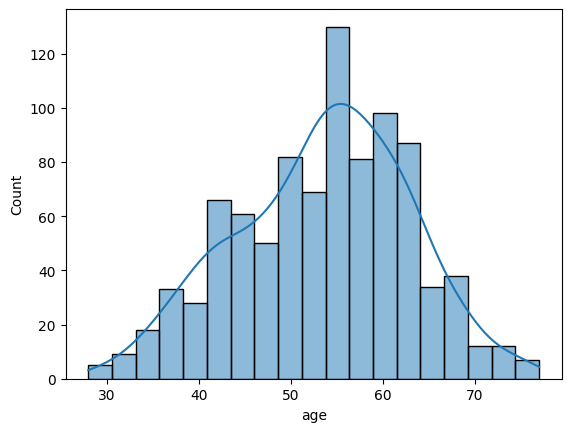

In [7]:
# Draw the graph of age distribution, which show the mostly patient age are
sns.histplot(df['age'], kde=True)

Mean : 53.51086956521739
Median : 54.0
Mode : 0    54
Name: age, dtype: int64


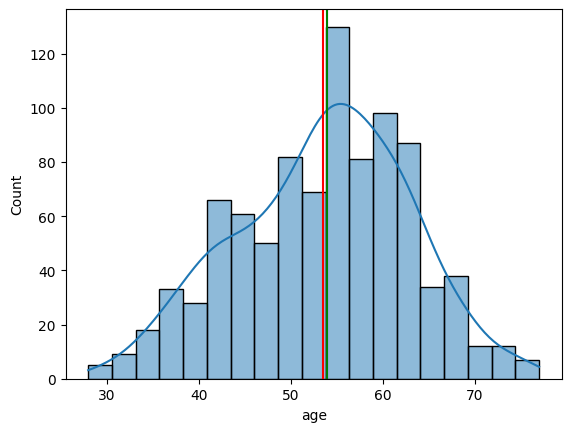

In [8]:
sns.histplot(df['age'], kde=True)
plt.axvline(df['age'].mean(), color='RED')
plt.axvline(df['age'].median(), color='magenta')
plt.axvline(df['age'].mode()[0], color='Green')

# print the values of mean, median and mode
print('Mean :', df['age'].mean())
print('Median :', df['age'].median())
print('Mode :', df['age'].mode())

In [9]:
fig = px.histogram(data_frame=df, x='age', color='sex')
fig.show()

In [10]:
# Display the total values counts of male and female who's heart patient 
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [11]:
# display the % of male and female 
print('The percentage of Female heart disease patients',(920-194)/920 * 100 )
print('The percentage of Male heart disease patients',(920-726)/920 * 100 )

The percentage of Female heart disease patients 78.91304347826087
The percentage of Male heart disease patients 21.086956521739133


In [12]:
# find the values counts of sex column age wise for analyzing age distributions within different gender groups
df.groupby('sex')['age'].value_counts()

sex     age
Female  54     15
        51     11
        62     10
        43      9
        48      9
               ..
Male    77      2
        28      1
        31      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

In [13]:
# lets explore the dataset columns
df['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [14]:
# total number of patients are different countries are here
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

In [15]:
# here we showing that total number of patients male and female with different countries
df.groupby('dataset')['sex'].value_counts()

dataset        sex   
Cleveland      Male      207
               Female     97
Hungary        Male      212
               Female     81
Switzerland    Male      113
               Female     10
VA Long Beach  Male      194
               Female      6
Name: count, dtype: int64

In [16]:
# sns.countplot(data=df, x='dataset' , hue='sex')
fig = px.bar(df, x='dataset', color='sex')
fig.show()

In [17]:
# here i show the plot of 4 different countries, age wise heart patients
fig = px.histogram(data_frame=df, x='age', color='dataset')
fig.show()

# in dataset 4 countries we will show the age wise mean, meidan and mode of each group

print('the mean of age column in diffenent dataset', df.groupby('dataset')['age'].mean())
print('the median of age column in diffenent dataset', df.groupby('dataset')['age'].median())
print('the mode of age column in diffenent dataset', df.groupby('dataset')['age'].agg(pd.Series.mode))

the mean of age column in diffenent dataset dataset
Cleveland        54.351974
Hungary          47.894198
Switzerland      55.317073
VA Long Beach    59.350000
Name: age, dtype: float64
the median of age column in diffenent dataset dataset
Cleveland        55.5
Hungary          49.0
Switzerland      56.0
VA Long Beach    60.0
Name: age, dtype: float64
the mode of age column in diffenent dataset dataset
Cleveland              58
Hungary                54
Switzerland            61
VA Long Beach    [62, 63]
Name: age, dtype: object


#### lets explore the cp column 

In [18]:
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

<Axes: xlabel='cp', ylabel='count'>

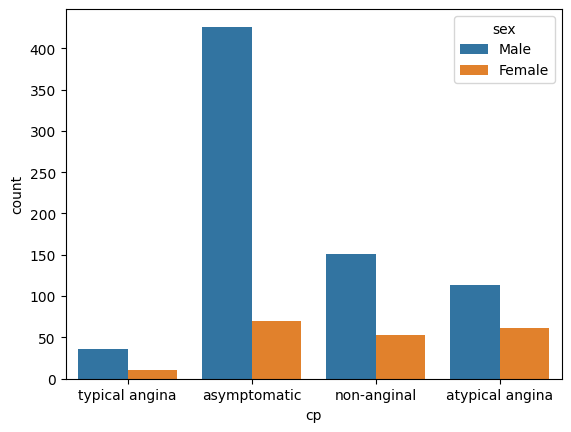

In [19]:
sns.countplot(df, x='cp', hue='sex')

In [20]:
fig = px.histogram(data_frame=df, x='cp', color='sex')
fig.show()

In [32]:
df.isnull().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
cp            0
dataset       0
id            0
age           0
sex           0
num           0
dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [34]:
df.thal.value_counts()

thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64

In [72]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()
missing_data_cols

['trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

In [71]:
# find only categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
# find only numerical columns
num_cols = df.select_dtypes(exclude='object').columns.tolist()

print(f'Categorical Columns: {cat_cols}')
print(f'Numerical Columns: {num_cols}')

Categorical Columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical Columns: ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']


In [38]:

categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex', 'num']
bool_cols = ['fbs', 'exang']
numeric_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

In [73]:
# define the function to impute the missing values in thal column

def impute_categorical_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)
        
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])
    
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =",root_mean_squared_error(y_test, y_pred), "\n")
    # squared=True
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

In [74]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64

In [75]:
import warnings
warnings.filterwarnings('ignore')
# impute missing values using our functions
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df[col].isnull().sum() / len(df)) * 100, 2))+"%")
    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        df[col] = impute_continuous_missing_data(col)
    else:
        pass


Missing Values trestbps : 6.41%
MAE = 13.263641618497111 

RMSE = 16.987546424543233 

R2 = 0.09897029201005003 

Missing Values chol : 3.26%
MAE = 45.436797752808985 

RMSE = 64.12649547503834 

R2 = 0.6742430740319351 

Missing Values fbs : 9.78%
The feature 'fbs' has been imputed with 80.12 accuracy

Missing Values restecg : 0.22%
The feature 'restecg' has been imputed with 65.22 accuracy

Missing Values thalch : 5.98%
MAE = 16.80479768786127 

RMSE = 21.764121334357778 

R2 = 0.31123417479783777 

Missing Values exang : 5.98%
The feature 'exang' has been imputed with 80.35 accuracy

Missing Values oldpeak : 6.74%
MAE = 0.5624651162790698 

RMSE = 0.7906031036125905 

R2 = 0.4045093106647514 

Missing Values slope : 33.59%
The feature 'slope' has been imputed with 65.85 accuracy

Missing Values ca : 66.41%
The feature 'ca' has been imputed with 67.74 accuracy

Missing Values thal : 52.83%
The feature 'thal' has been imputed with 70.11 accuracy



In [76]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

### Dealing with outliers

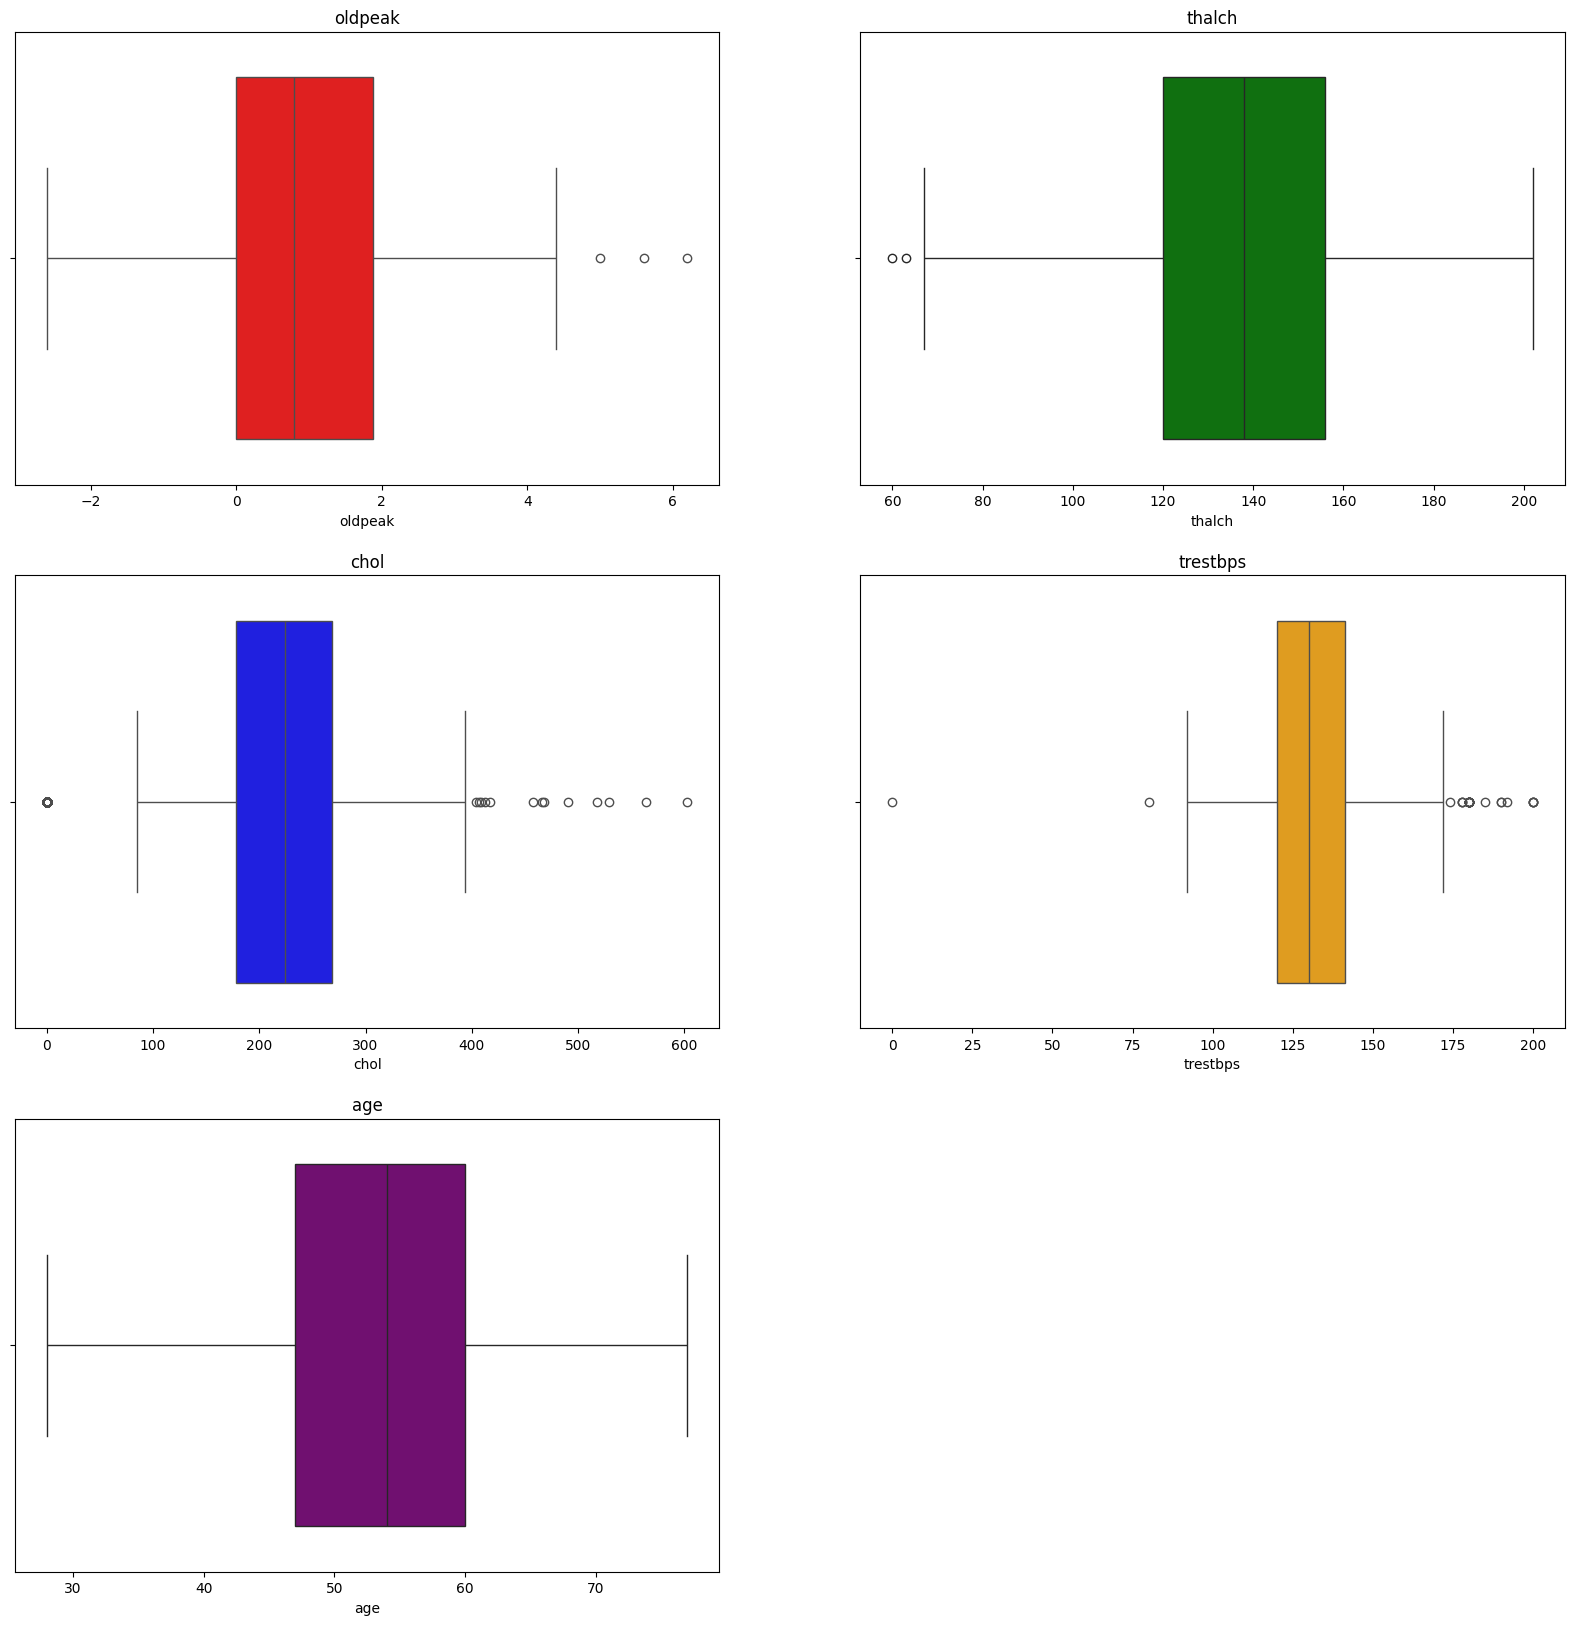

In [78]:
# ceate box solots for all numeric columns using for loop and subplot
plt.figure(figsize=(20,20))

colors = ['red', 'green', 'blue', 'orange', 'purple']

for i, col in enumerate(numeric_cols): 
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=df[col], color=colors[i])
    plt.title(col)
plt.show()    

In [81]:
# print the row from df where trestbps value i 0
df[df['trestbps'] == 0]

# remove this row from dataset
df = df[df['trestbps'] != 0]

In [84]:
df[df['chol'] == 0]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
597,598,32,Male,Switzerland,typical angina,95.00,0.0,False,normal,127.00,False,0.700,upsloping,0.0,normal,1
598,599,34,Male,Switzerland,asymptomatic,115.00,0.0,False,normal,154.00,False,0.200,upsloping,0.0,reversable defect,1
599,600,35,Male,Switzerland,asymptomatic,124.79,0.0,False,normal,130.00,True,1.191,flat,0.0,reversable defect,3
600,601,36,Male,Switzerland,asymptomatic,110.00,0.0,False,normal,125.00,True,1.000,flat,0.0,fixed defect,1
601,602,38,Female,Switzerland,asymptomatic,105.00,0.0,False,normal,166.00,False,2.800,upsloping,0.0,normal,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,819,43,Male,VA Long Beach,asymptomatic,122.00,0.0,False,normal,120.00,False,0.500,upsloping,0.0,reversable defect,1
819,820,63,Male,VA Long Beach,non-anginal,130.00,0.0,True,st-t abnormality,160.00,False,3.000,flat,0.0,fixed defect,0
822,823,48,Male,VA Long Beach,non-anginal,102.00,0.0,False,st-t abnormality,110.00,True,1.000,downsloping,0.0,reversable defect,1
839,840,56,Male,VA Long Beach,asymptomatic,143.33,0.0,False,lv hypertrophy,119.73,True,2.204,flat,0.0,reversable defect,1


### Machine learning

In [87]:
df['num'].value_counts()

num
0    411
1    265
2    109
3    106
4     28
Name: count, dtype: int64

The Target Column is num which is the predicted attribute. We will use this column to predict the heart disease. The unique values in this column are: [0, 1, 2, 3, 4], which states that there are 5 types of heart diseases.\n

0    = no heart disease \n
1    = mild heart disease \n
2    = moderate heart disease\n 
3    = severe heart disease \n 
4    = critical heart disease 

In [102]:
# split the data into x and y
X = df.drop('num' , axis =1)
y = df['num']

# encode the categorical column through label encoder
label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = label_encoder.fit_transform(X[col])
    else:
        pass

# encode X ata using separate label encoder for all categorical columns
# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.3, random_state=42)

    Enlist all the models that you will use to predict the heart disease. These models should be classifiers for multi-class classification.

1.  logistic regression
2.  KNN
3.  NB
4.  SVM
5.  Decision Tree
6.  Random Forest
7.  XGBoost
8.  GradientBoosting
9.  AdaBoost
10. lightGBM

In [103]:
# create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting' , GradientBoostingClassifier(random_state=42)),
    ('Support Vector Machine', SVC(random_state=42)),
    ('Logestic Regression', LogisticRegression(random_state=42)),
    ('k-Nearest Neighbors', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('ada boost', AdaBoostClassifier(random_state=42)),
    ('Naive base', GaussianNB())
]
best_model = None
best_accuracy = 0.0

# iterate over the models and evaluate their performance
for name, model in models: 
    # create a pipeline for each model 
    pipeline = Pipeline([ ('model', model)])

    # perform cross-validation
    scores =  cross_val_score(pipeline, X_train, y_train, cv=5)

    # calculate mean accuracy
    mean_accuracy = scores.mean()

    # Fit the pipeline on the trainind data
    pipeline.fit(X_train, y_train)

    # make prediction on the test data
    y_pred = pipeline.predict(X_test)

    # calculate accuracy score 
    accuracy = accuracy_score(y_test, y_pred)

    # print the performance metrics
    print("Model:", name)
    print("cross-validation Accuracy:", mean_accuracy)
    print("Test Accuray: ", accuracy)
    print()

    # check if the accuracy model has the best accuracy 
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline
# retrieve the best model 
print("Best Model : ", best_model)




Model: Random Forest
cross-validation Accuracy: 0.6531492248062015
Test Accuray:  0.6485507246376812

Model: Gradient Boosting
cross-validation Accuracy: 0.6484859496124031
Test Accuray:  0.6666666666666666

Model: Support Vector Machine
cross-validation Accuracy: 0.5785731589147287
Test Accuray:  0.5869565217391305

Model: Logestic Regression
cross-validation Accuracy: 0.5100654069767442
Test Accuray:  0.5217391304347826

Model: k-Nearest Neighbors
cross-validation Accuracy: 0.5754360465116279
Test Accuray:  0.5978260869565217

Model: Decision Tree
cross-validation Accuracy: 0.5940649224806202
Test Accuray:  0.6376811594202898

Model: ada boost
cross-validation Accuracy: 0.6531734496124031
Test Accuray:  0.6159420289855072

Model: Naive base
cross-validation Accuracy: 0.5708817829457364
Test Accuray:  0.5615942028985508

Best Model :  Pipeline(steps=[('model', GradientBoostingClassifier(random_state=42))])


#### Ouputs: 

1. The minimum age to have to a heart disease starts from 28 year old
2. The highest number of people with heart disease are aged 54-55 years.
3. The percentage of Female heart disease patients 78.91304347826087
4. The percentage of Male heart disease patients 21.086956521739133
5. The 529 male patients are more the female heart disease patienet.
6. Heigest number of people are came from Cleveland 304.\
    6.1.    The higest number of female heart disease patient are came from Cleaveland (97) and lowest from Va long beach(VA Long Beach) \
    6.2.    The higest number of male heaet disease patient are in Hungary (212) and lowest from switzerland (113)
7. Mean , median and mode of age column with different countries 
8. How many patients are whos different symptome \
        asymptomatic       496 \
        non-anginal        204 \
        atypical angina    174 \
        typical angina      46 
9. check the missing values in categorical values and impute
10. check the outlier and remove the outlier
11. i check 'chol' column and remove this (Row deleted)
